In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# Plot
plot_directory = 'result/plot_set'

In [3]:
colors = [
	'#FF0000',
	'#00FFFF',
	'#0000FF',
	'#00008B',
	'#ADD8E6',
	'#800080',
	'#7FFFD4',
	'#008000',
	'#FF00FF',
	'#FFC0CB',
	'#C0C0C0',
	'#FFA500',
	'#000000',
	'#800000',
]

In [4]:
def load_json_file(file_path):
	try:
		with open(file_path, 'r') as file:
			data = json.load(file)
		return data
	
	except Exception as e:
		print(f"An error occurred while loading the JSON file: {e}")
		return None

In [5]:
def extract_fpss(metric_list):
	return list(metric_list[list(metric_list.keys())[0]][0]['metric'].keys())

In [6]:
def to_accuracy_vector(accuracy_result_seq, fpss, type='F1'):
	accuracy_vector = []
	for fps in fpss:
		accuracy_vector.append(accuracy_result_seq[fps][type])
	
	return accuracy_vector

In [7]:
def plot_scatter(xs, ys, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	plt.scatter(xs, ys, c=colors[0], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [8]:
def plot_scatter_label(xs, ys, labels, x_label, y_label, title, fig_size=(8, 8)):
	plt.figure(figsize=fig_size)
	for i in range(len(xs)):
		plt.scatter(xs[i], ys[i], c=colors[labels[i]], s=30, alpha=0.5)
	plt.title(title)
	plt.xlabel(x_label)
	plt.ylabel(y_label)
	plt.show()

In [9]:
def filter_list_index(input_list, indices_to_remove):
	return [item for i, item in enumerate(input_list) if i not in indices_to_remove]

In [10]:
def round_float_to_sigfigs(number, sigfigs):
	return round(number, sigfigs)

## Plot

In [11]:
omv_features = ["Left-Top", "Right-Top", "Left-Bottom", "Right-Bottom", "Object-Amount", "Confidence", "IOU"]

In [12]:
plot_filenames = sorted(os.listdir(plot_directory))
plot_video_names = sorted(list(set([f.split('_')[0] for f in plot_filenames])))

In [13]:
fpss = extract_fpss(load_json_file(os.path.join(plot_directory, plot_video_names[0] + "_Accuracy_Result.json")))

In [14]:
omv_videos = []
acc_videos = []

for v in plot_video_names:
	omv_dict = {}
	for fps in fpss:
		omv_dict[fps] = []
	acc_list = []

	accuracy_result = load_json_file(os.path.join(plot_directory, v + "_Accuracy_Result.json"))
	movement_result = load_json_file(os.path.join(plot_directory, v + "_Movement_Result.json"))

	for class_idx in list(accuracy_result.keys()):
		for i in range(len(accuracy_result[class_idx])):
			accuracy_vector = to_accuracy_vector(accuracy_result[class_idx][i]['metric'], fpss)
			acc_list.append(accuracy_vector)

			for fps in fpss:
				movement_vector = movement_result[class_idx][i]['movement'][fps]
				omv_dict[fps].append(movement_vector)
	
	omv_videos.append(omv_dict)
	acc_videos.append(acc_list)

In [15]:
# Corr

# for i in range(len(plot_video_names)):
# 	video_name = plot_video_names[i]
# 	for k in range(len(fpss)):
# 		for j in range(len(omv_videos[0][fpss[0]][0])):	
# 			fps = fpss[k]

# 			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
# 			acc_fps = list(np.array(acc_videos[i])[:, k])

# 			# Remove Outliers
# 			outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
# 			omv_fps_clean = filter_list_index(omv_fps, outlier_index)
# 			acc_fps_clean = filter_list_index(acc_fps, outlier_index)

# 			title = f'{video_name}; OMV Feature {j} ({omv_features[j]}); FPS: {fps}'

# 			correlation_matrix = np.corrcoef(omv_fps_clean, acc_fps_clean)
# 			correlation_coefficient = correlation_matrix[0, 1]
# 			print(f"{title} -> Corr: {round_float_to_sigfigs(correlation_coefficient, 3)}")
# 			# plot_scatter(omv_fps_clean, acc_fps_clean, 'OMV Feature', 'ACC', title)

# 		print("")

# New Code

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures

In [17]:
def transpose_array(arr):
    # Transpose the input array using zip and map it back to a list
    return [list(row) for row in zip(*arr)]

In [18]:
def my_train_test_split(x, y, test_size):
	split_point = int(len(x) * (1-test_size))
	return x[0:split_point], x[split_point:len(x)], y[0:split_point], y[split_point:len(x)]

In [19]:
def root_mean_squared_error(y_train, y_train_pred):
	return np.sqrt(mean_squared_error(y_train, y_train_pred))

In [20]:
OMV_FEATURE_INDEX = [5, 6]
TEST_SIZE = 0.2

In [21]:
# Dataset Build

dataset = {}

for i in range(len(plot_video_names)):
	video_name = plot_video_names[i]
	dataset[video_name] = {}
	
	for k in range(len(fpss)):
		fps = fpss[k]
		dataset[video_name][fps] = {}
		y_all = None
		x_all_t = []

		for j in range(len(omv_videos[0][fpss[0]][0])):	
			fps = fpss[k]

			omv_fps = list(np.array(omv_videos[i][fps])[:, j])
			acc_fps = list(np.array(acc_videos[i])[:, k])

			# Remove Outliers
			outlier_index = [l for l in range(len(omv_fps)) if omv_fps[l] == -1]
			omv_fps_clean = filter_list_index(omv_fps, outlier_index)
			acc_fps_clean = filter_list_index(acc_fps, outlier_index)

			if j == 0:
				y_all = acc_fps_clean.copy()
			if j in OMV_FEATURE_INDEX:
				x_all_t.append(omv_fps_clean.copy())
		
		x_all = transpose_array(x_all_t)
		dataset[video_name][fps]['y_all'] = y_all
		dataset[video_name][fps]['x_all'] = x_all
			

In [22]:
def lr_inference(x_train, x_test, y_train, y_test):
	lr_model = LinearRegression()
	lr_model.fit(x_train, y_train)

	y_train_pred = lr_model.predict(x_train)
	y_test_pred = lr_model.predict(x_test)

	train_mse = root_mean_squared_error(y_train, y_train_pred)
	test_mse = root_mean_squared_error(y_test, y_test_pred)

	_tr_list = []
	for _p, _y in zip(y_train, y_train_pred):
		_tr_list.append(root_mean_squared_error([_p], [_y]))
	
	plt.figure()
	ax = plt.subplot(211)
	ax.plot(_tr_list)

	_te_list = []
	for _p, _y in zip(y_test, y_test_pred):
		_te_list.append(root_mean_squared_error([_p], [_y]))
	
	bx = plt.subplot(212)
	bx.plot(_te_list)
	plt.show()
	
	# print(f"Linear Regression Train MSE: {round(train_mse, 4)}")
	# print(f"Linear Regression Test MSE: {round(test_mse, 4)}")

	return train_mse, test_mse

In [23]:
def pr_inference(x_train, x_test, y_train, y_test):
	poly_train = PolynomialFeatures(degree=3)
	poly_test = PolynomialFeatures(degree=3)
	x_train_poly = poly_train.fit_transform(x_train)
	x_test_poly = poly_test.fit_transform(x_test)

	pr_model = LinearRegression()
	pr_model.fit(x_train_poly, y_train)

	y_train_pred = pr_model.predict(x_train_poly)
	y_test_pred = pr_model.predict(x_test_poly)

	train_mse = root_mean_squared_error(y_train, y_train_pred)
	test_mse = root_mean_squared_error(y_test, y_test_pred)

	_tr_list = []
	for _p, _y in zip(y_train, y_train_pred):
		_tr_list.append(root_mean_squared_error([_p], [_y]))
	
	plt.figure()
	ax = plt.subplot(211)
	ax.plot(_tr_list)

	_te_list = []
	for _p, _y in zip(y_test, y_test_pred):
		_te_list.append(root_mean_squared_error([_p], [_y]))
	
	bx = plt.subplot(212)
	bx.plot(_te_list)
	plt.show()

	# print(f"Polynomial Regression Train MSE: {round(train_mse, 4)}")
	# print(f"Polynomial Regression Test MSE: {round(test_mse, 4)}")

	return train_mse, test_mse

In [24]:
def rfr_inference(x_train, x_test, y_train, y_test):
	rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)
	rfr_model.fit(x_train, y_train)

	y_train_pred = rfr_model.predict(x_train)
	y_test_pred = rfr_model.predict(x_test)

	train_mse = root_mean_squared_error(y_train, y_train_pred)
	test_mse = root_mean_squared_error(y_test, y_test_pred)

	# _tr_list = []
	# for _p, _y in zip(y_train, y_train_pred):
	# 	_tr_list.append(root_mean_squared_error([_p], [_y]))
	
	# plt.figure()
	# ax = plt.subplot(111)
	# ax.plot(_tr_list)

	# _te_list = []
	# for _p, _y in zip(y_test, y_test_pred):
	# 	_te_list.append(root_mean_squared_error([_p], [_y]))
	# ax.plot(_te_list)
	# ax.set_xlim([0, 70])
	# plt.show()

	_tr_list = []
	for _p, _y in zip(y_train, y_train_pred):
		_tr_list.append(root_mean_squared_error([_p], [_y]))
	
	plt.figure()
	ax = plt.subplot(211)
	ax.plot(_tr_list)

	_te_list = []
	for _p, _y in zip(y_test, y_test_pred):
		_te_list.append(root_mean_squared_error([_p], [_y]))
	
	bx = plt.subplot(212)
	bx.plot(_te_list)
	plt.show()

	# print(f"Random Forest Regression Train MSE: {round(train_mse, 4)}")
	# print(f"Random Forest Regression Test MSE: {round(test_mse, 4)}")

	return train_mse, test_mse

In [25]:
def svr_inference(x_train, x_test, y_train, y_test):
	svr_model = SVR(kernel='rbf', C=1e3, gamma=0.1)
	svr_model.fit(x_train, y_train)

	y_train_pred = svr_model.predict(x_train)
	y_test_pred = svr_model.predict(x_test)

	train_mse = root_mean_squared_error(y_train, y_train_pred)
	test_mse = root_mean_squared_error(y_test, y_test_pred)

	_tr_list = []
	for _p, _y in zip(y_train, y_train_pred):
		_tr_list.append(root_mean_squared_error([_p], [_y]))
	
	plt.figure()
	ax = plt.subplot(211)
	ax.plot(_tr_list)

	_te_list = []
	for _p, _y in zip(y_test, y_test_pred):
		_te_list.append(root_mean_squared_error([_p], [_y]))
	
	bx = plt.subplot(212)
	bx.plot(_te_list)
	plt.show()

	# print(f"Support Vector Regression Train MSE: {round(train_mse, 4)}")
	# print(f"Support Vector Regression Test MSE: {round(test_mse, 4)}")

	return train_mse, test_mse

In [26]:
def knn_inference(x_train, x_test, y_train, y_test):
	knn_model = KNeighborsRegressor(n_neighbors=5)  # Using k = 5 neighbors
	knn_model.fit(x_train, y_train)

	y_train_pred = knn_model.predict(x_train)
	y_test_pred = knn_model.predict(x_test)

	train_mse = root_mean_squared_error(y_train, y_train_pred)
	test_mse = root_mean_squared_error(y_test, y_test_pred)

	_tr_list = []
	for _p, _y in zip(y_train, y_train_pred):
		_tr_list.append(root_mean_squared_error([_p], [_y]))
	
	plt.figure()
	ax = plt.subplot(211)
	ax.plot(_tr_list)

	_te_list = []
	for _p, _y in zip(y_test, y_test_pred):
		_te_list.append(root_mean_squared_error([_p], [_y]))
	
	bx = plt.subplot(212)
	bx.plot(_te_list)
	plt.show()

	# print(f"K-Nearest Neighbors Train MSE: {round(train_mse, 4)}")
	# print(f"K-Nearest Neighbors Test MSE: {round(test_mse, 4)}")

	return train_mse, test_mse

FPS: 1


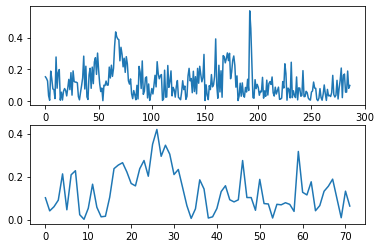

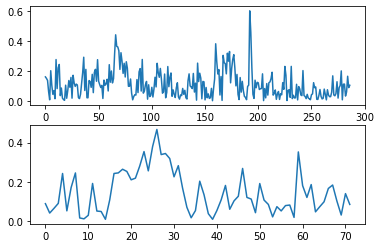

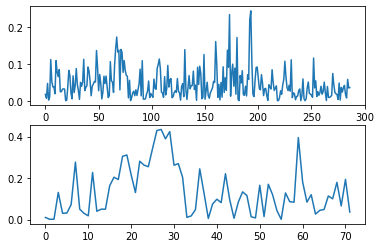

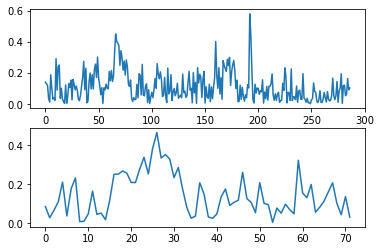

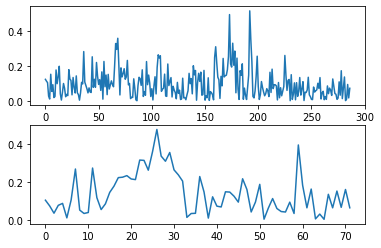

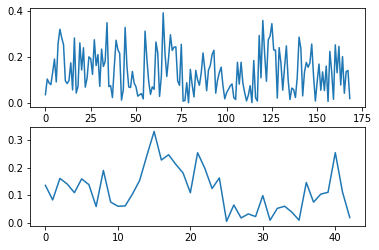

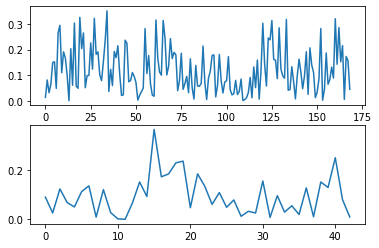

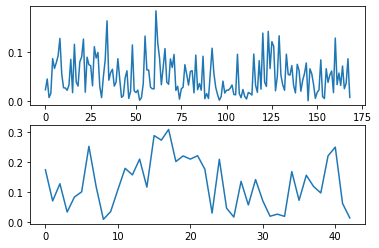

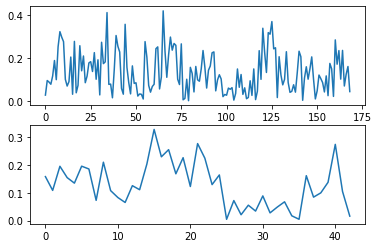

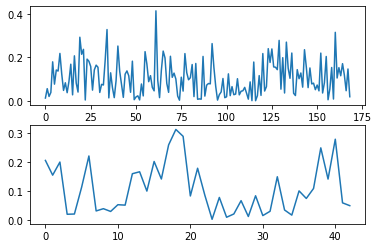

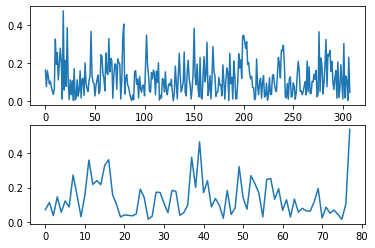

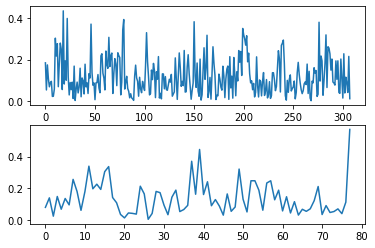

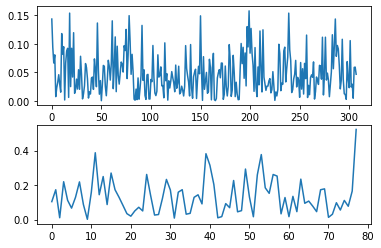

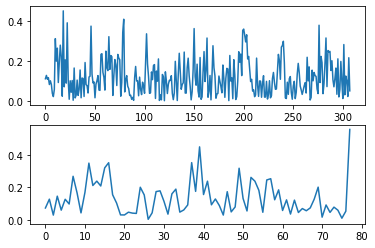

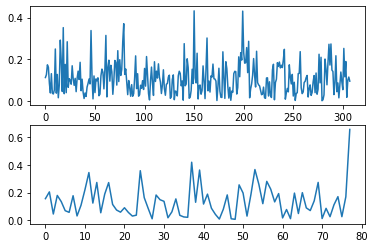

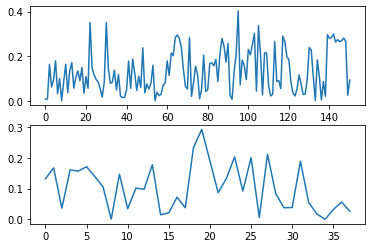

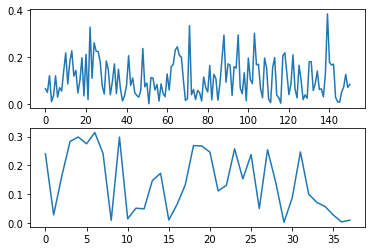

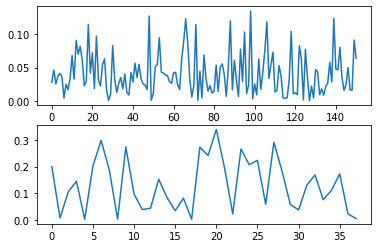

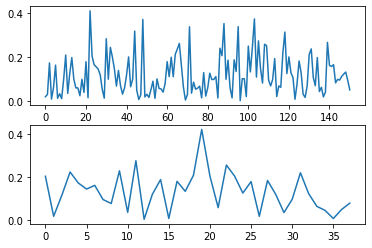

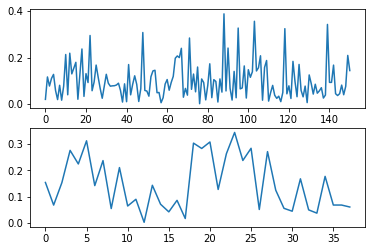

LR
[0.14812452 0.16372184 0.14991724 0.16272217]
[0.16536204 0.1428432  0.17583705 0.12882028]
PR
[0.14414525 0.14961836 0.14823181 0.13507184]
[0.18043969 0.12513676 0.17488387 0.17827357]
RFR
[0.06097852 0.06283897 0.05959655 0.05149378]
[0.18072251 0.15412349 0.16994045 0.16484271]
SVR
[0.14613491 0.1631303  0.14955242 0.14964078]
[0.17912179 0.15200705 0.17354985 0.16054688]
KNN
[0.12730775 0.1314295  0.1321456  0.12739162]
[0.17865616 0.13870914 0.17972862 0.17987491]

FPS: 2


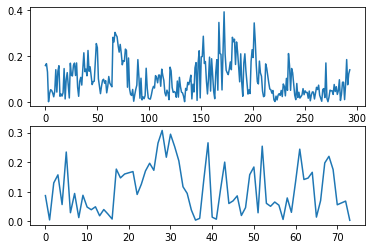

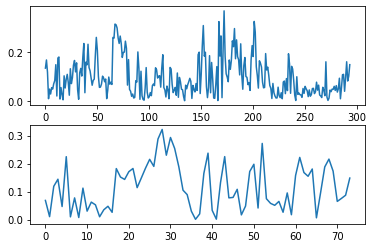

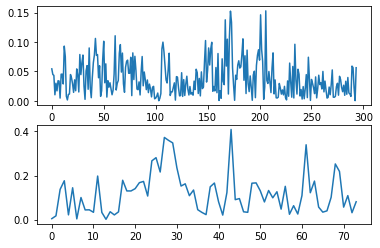

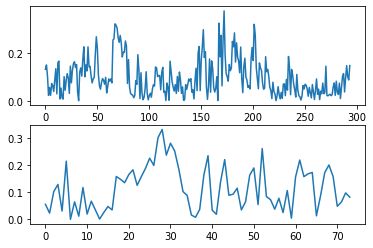

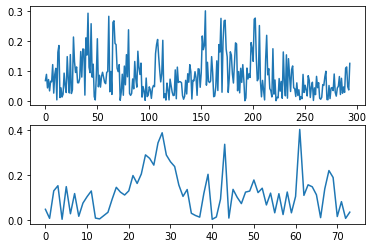

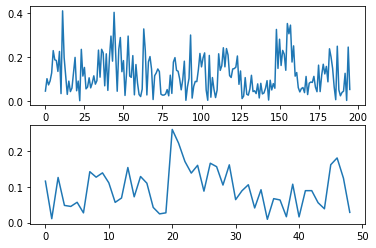

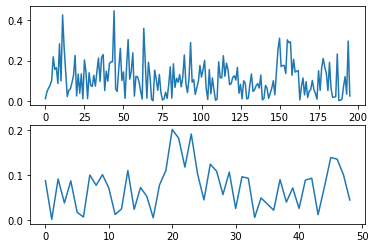

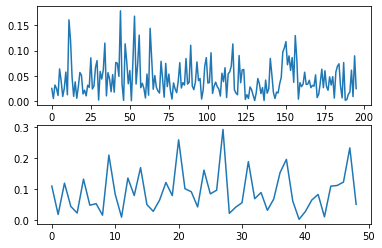

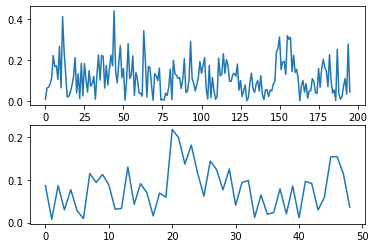

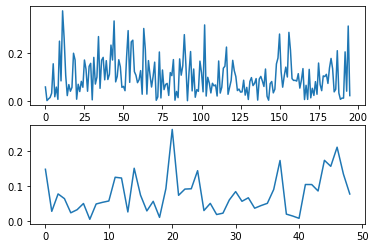

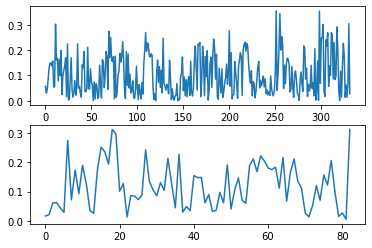

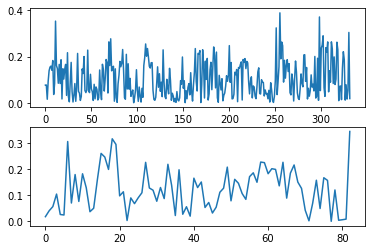

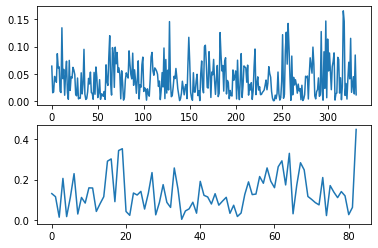

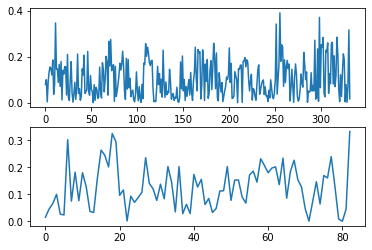

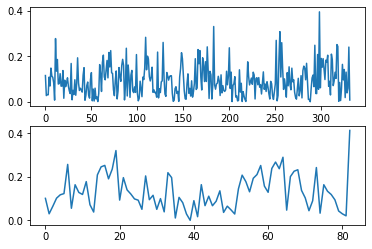

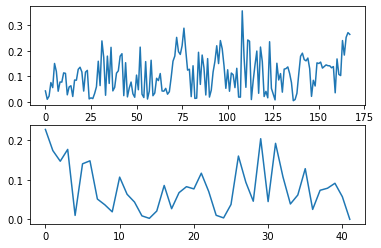

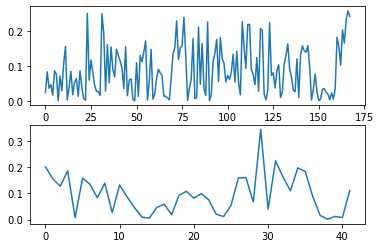

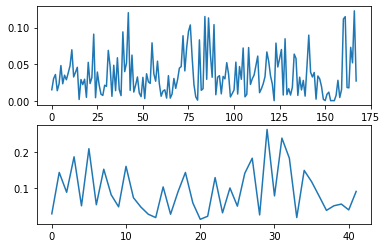

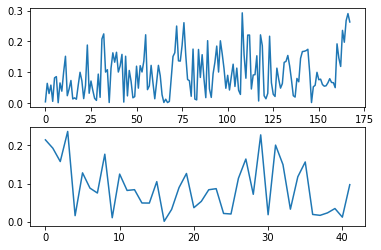

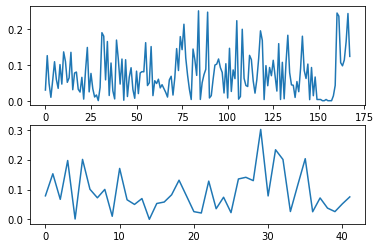

LR
[0.12490155 0.14860662 0.1309324  0.13073303]
[0.13759419 0.11141892 0.14355772 0.09940731]
PR
[0.1223272  0.13967061 0.12919922 0.11211892]
[0.14378787 0.08854699 0.14730661 0.1217142 ]
RFR
[0.04851481 0.05541451 0.05163557 0.04527855]
[0.15339184 0.11344999 0.16298645 0.11215702]
SVR
[0.12344907 0.14314452 0.13049656 0.11795328]
[0.14194536 0.09489518 0.1499796  0.11206956]
KNN
[0.10604298 0.12707402 0.11502477 0.09664395]
[0.15338922 0.09593418 0.15607567 0.11543688]

FPS: 3


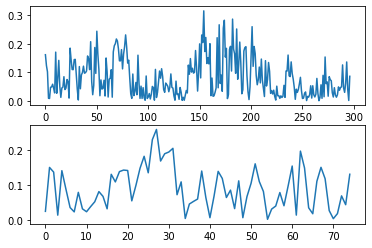

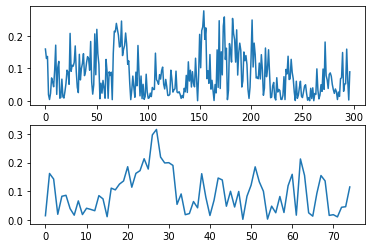

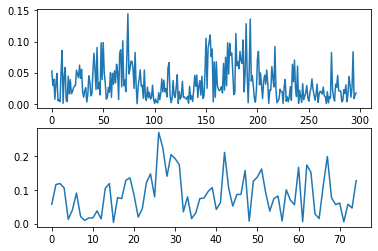

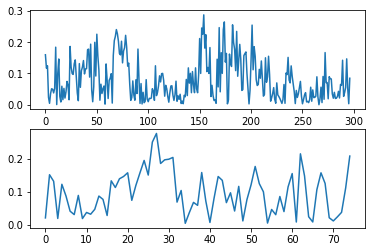

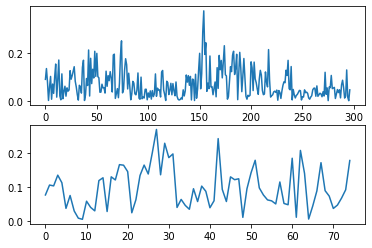

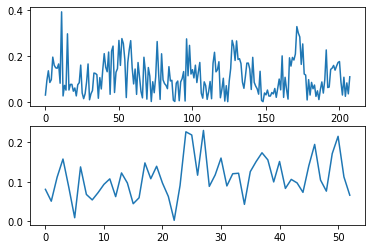

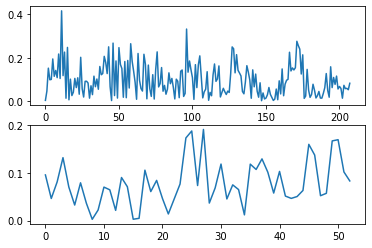

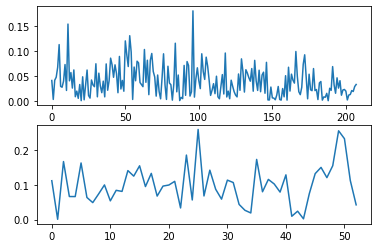

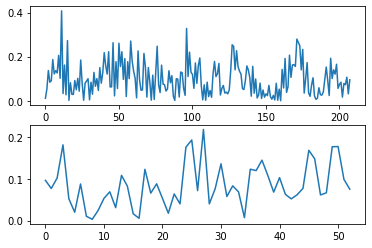

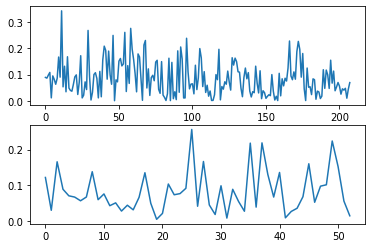

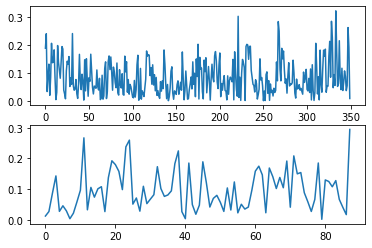

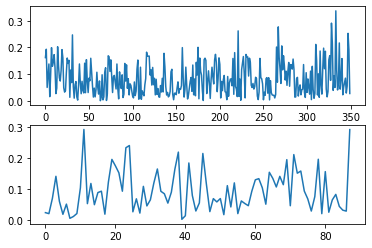

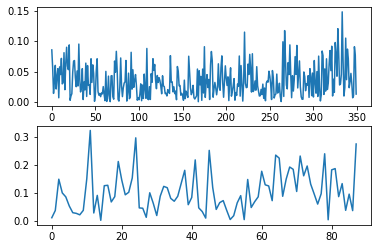

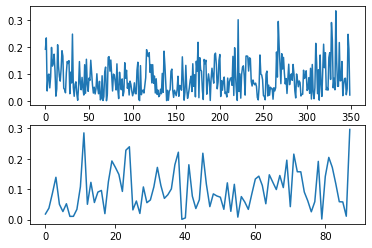

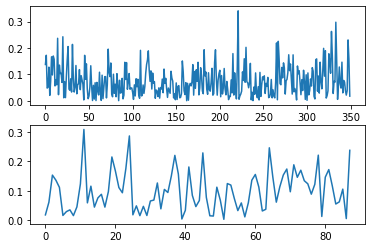

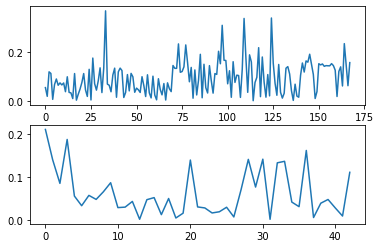

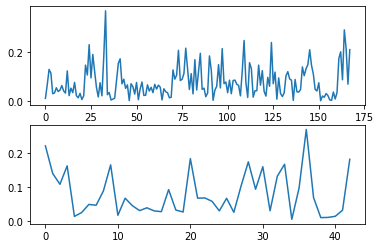

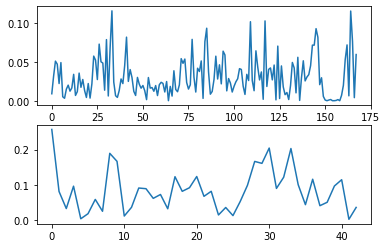

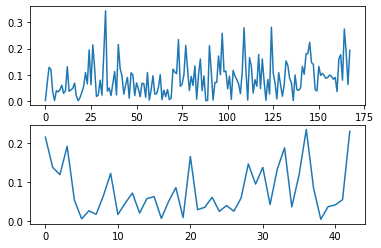

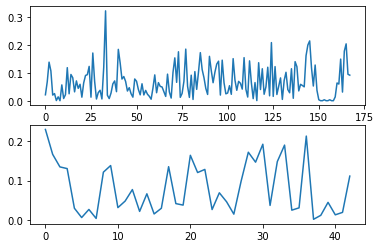

LR
[0.10549532 0.13416265 0.10369189 0.11798373]
[0.10824265 0.12174429 0.11828834 0.08260773]
PR
[0.10236708 0.12157913 0.10169011 0.10108588]
[0.11917697 0.09178915 0.11575985 0.1030546 ]
RFR
[0.04323553 0.05032133 0.04375041 0.03937451]
[0.1064503  0.11550958 0.12731669 0.10340213]
SVR
[0.10342818 0.12451441 0.10294245 0.10806184]
[0.11648484 0.09958367 0.12005024 0.10155971]
KNN
[0.09226854 0.10777581 0.09367134 0.08714407]
[0.1153136  0.10171171 0.12093101 0.10459039]

FPS: 5


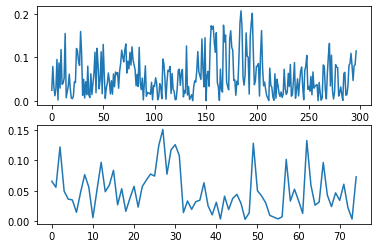

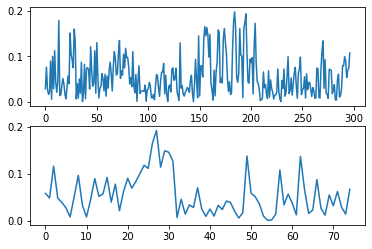

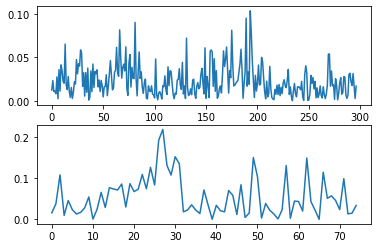

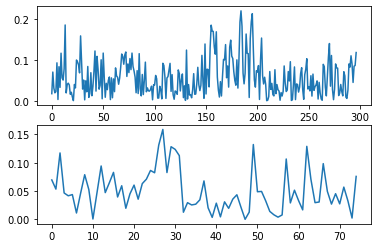

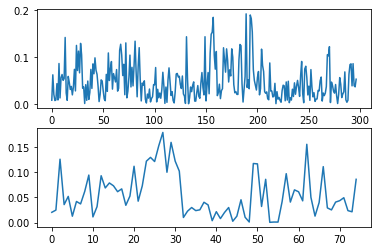

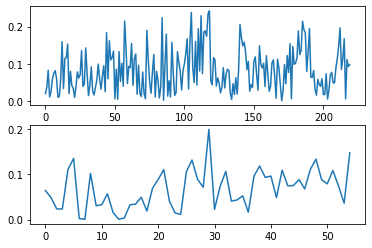

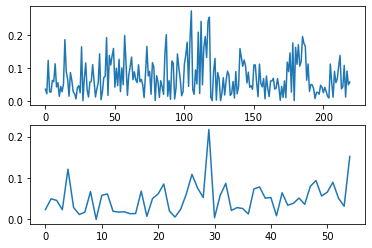

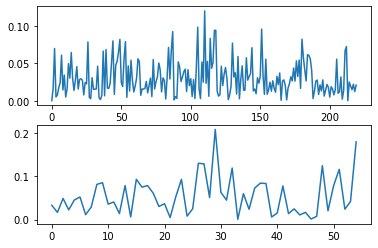

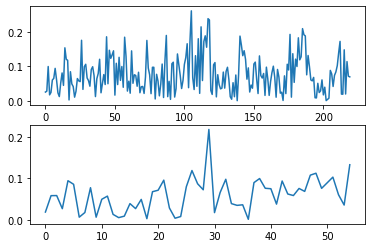

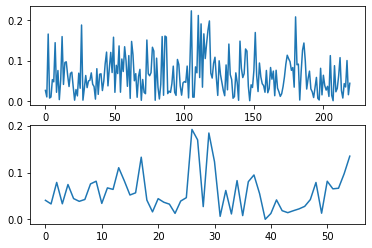

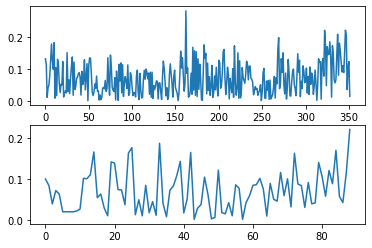

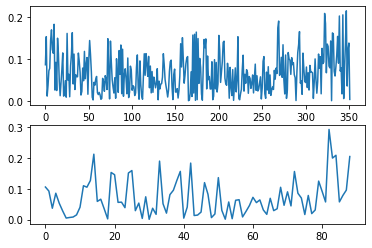

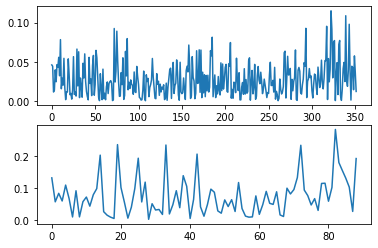

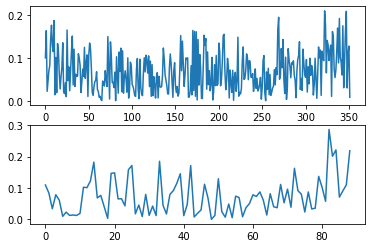

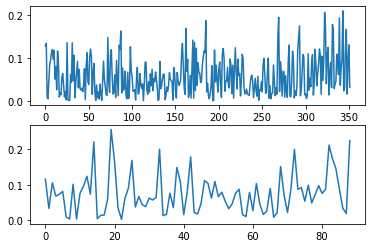

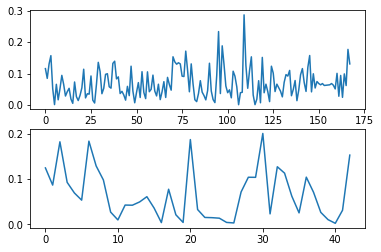

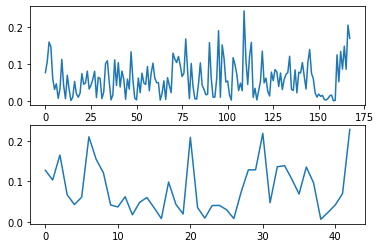

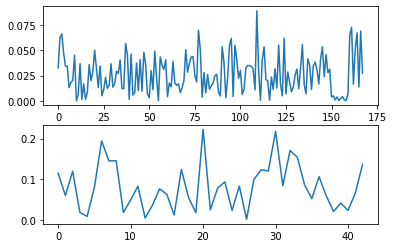

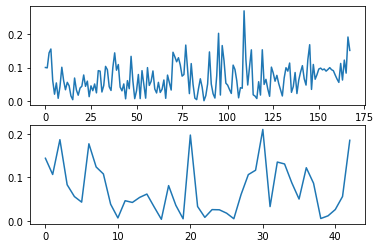

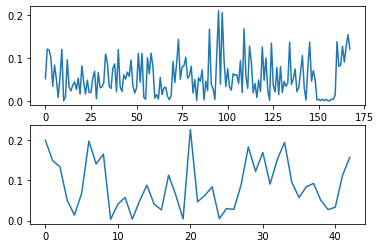

LR
[0.07276999 0.10087015 0.08581586 0.083796  ]
[0.06087872 0.07999191 0.08664985 0.08748484]
PR
[0.07081959 0.0915835  0.08138939 0.07631993]
[0.07032941 0.06371737 0.0928551  0.10271954]
RFR
[0.02889334 0.03813822 0.03481944 0.03221887]
[0.07373029 0.07053202 0.09810334 0.10003898]
SVR
[0.07294507 0.09507726 0.08224604 0.08232013]
[0.06287096 0.07236661 0.0942235  0.09372824]
KNN
[0.06140984 0.08021744 0.07213006 0.07051519]
[0.07127057 0.07340088 0.09545922 0.10754449]

FPS: 6


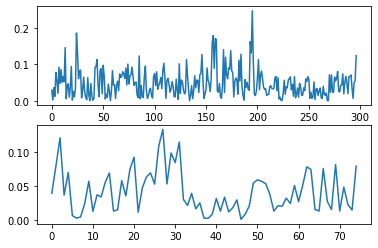

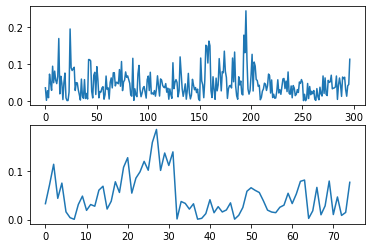

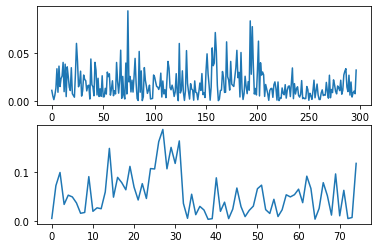

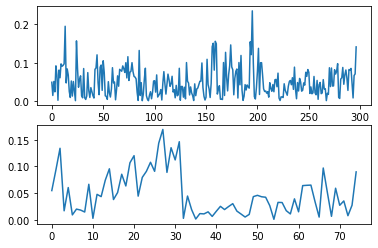

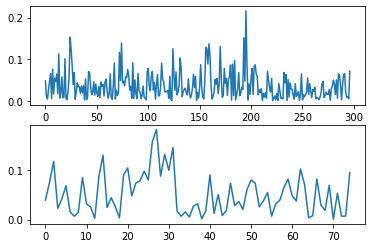

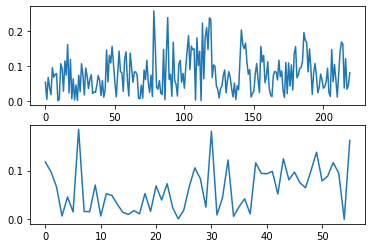

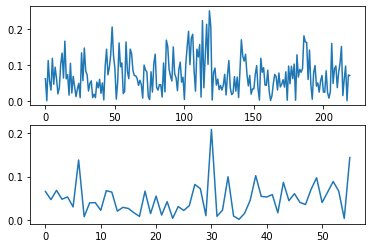

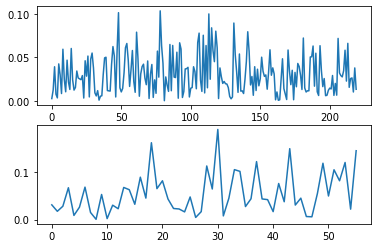

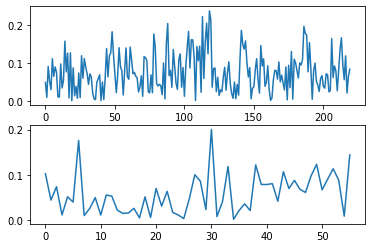

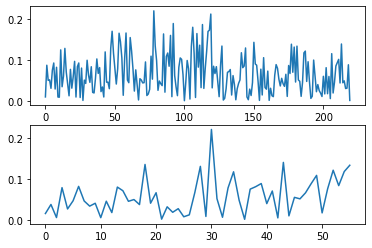

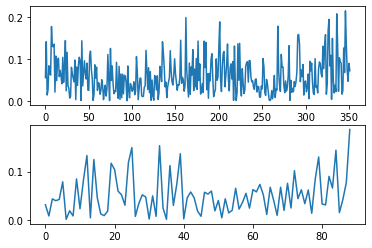

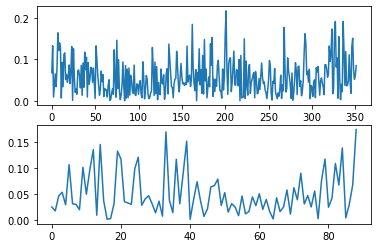

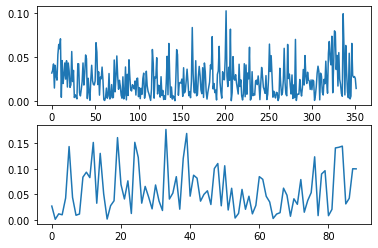

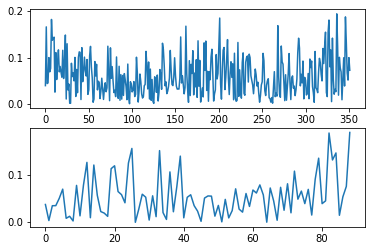

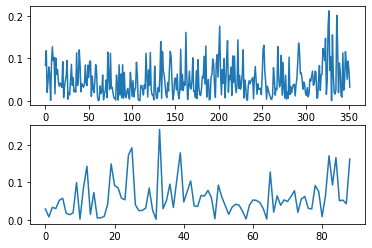

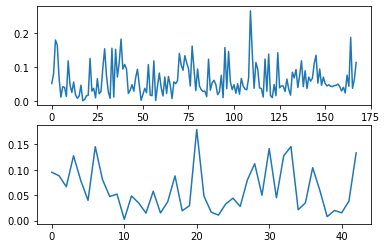

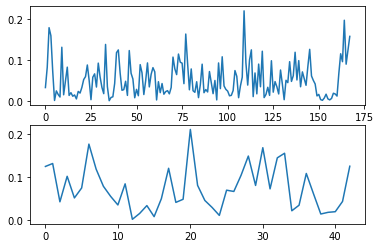

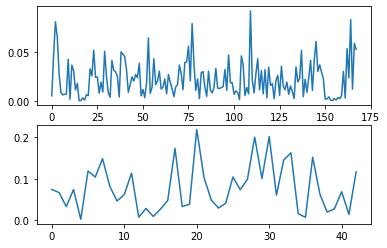

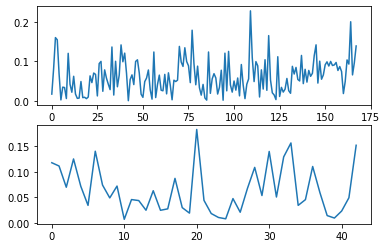

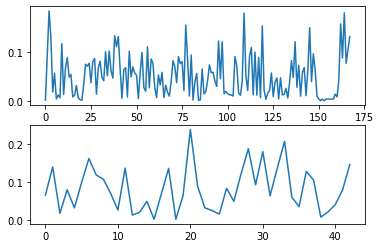

LR
[0.06122701 0.09553564 0.07354859 0.07668071]
[0.0519456  0.07830684 0.06631028 0.07634217]
PR
[0.05850031 0.08892064 0.07056909 0.06803896]
[0.06405553 0.06271394 0.06547772 0.09054585]
RFR
[0.02325778 0.0378353  0.03030602 0.02900678]
[0.0702342  0.07133973 0.07470267 0.09689097]
SVR
[0.06219329 0.09169779 0.07309103 0.07598643]
[0.06364708 0.07356938 0.07065617 0.07956626]
KNN
[0.04897711 0.08119586 0.06308845 0.06675869]
[0.0664696  0.07340322 0.07675275 0.10120856]

FPS: 10


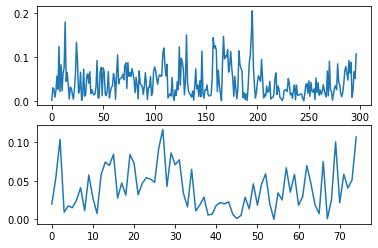

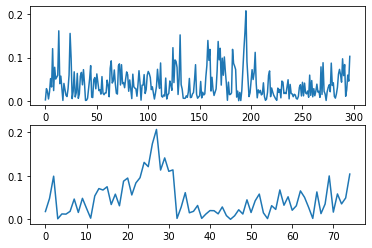

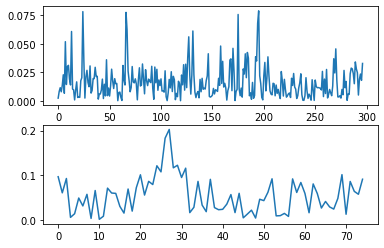

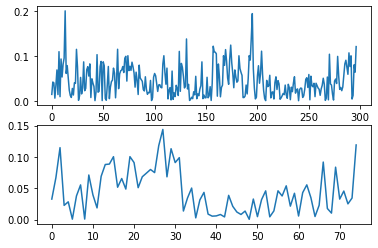

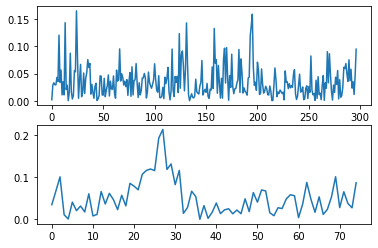

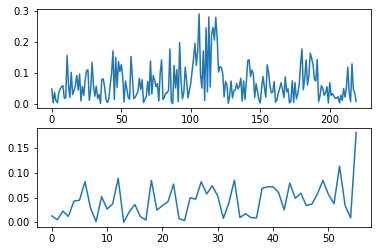

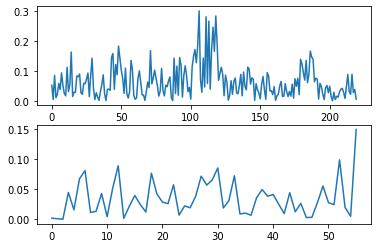

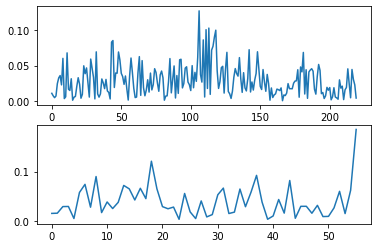

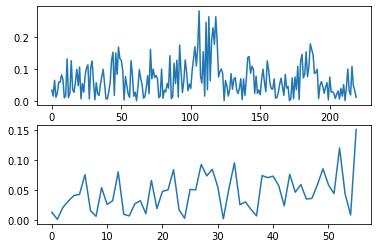

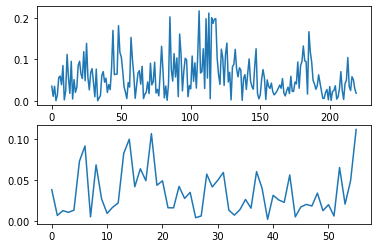

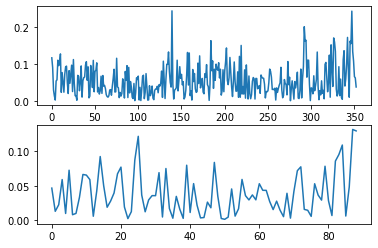

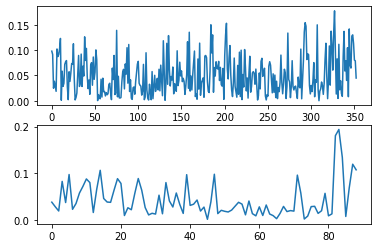

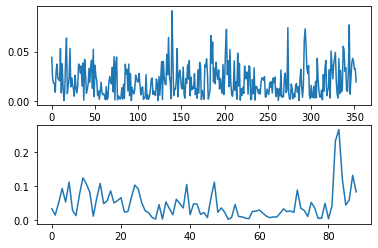

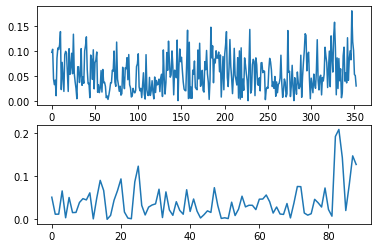

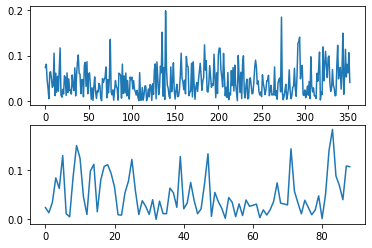

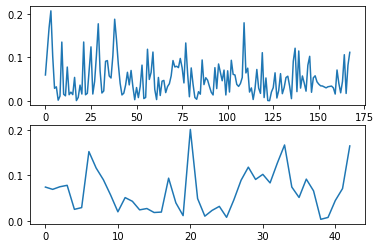

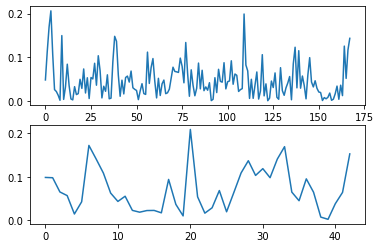

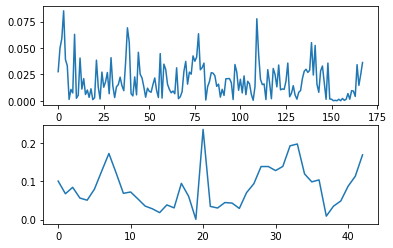

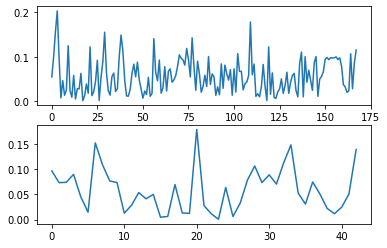

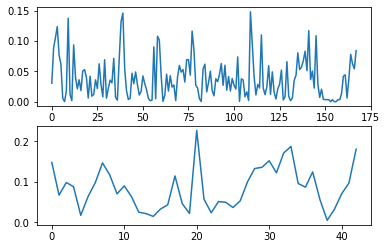

LR
[0.05534049 0.0885964  0.06873959 0.06612794]
[0.04960447 0.05538278 0.04991352 0.08094585]
PR
[0.05202488 0.08462612 0.06242092 0.06107743]
[0.06410445 0.04620674 0.0574914  0.08739749]
RFR
[0.02145744 0.0366679  0.02580733 0.02529222]
[0.06855367 0.05144065 0.06493138 0.10143228]
SVR
[0.0561494  0.08700979 0.06562755 0.06916839]
[0.05758533 0.05532076 0.05776607 0.07367632]
KNN
[0.04535374 0.07511317 0.05431387 0.05082867]
[0.06627226 0.0450091  0.06509945 0.09977611]

FPS: 15


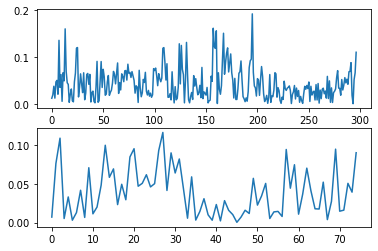

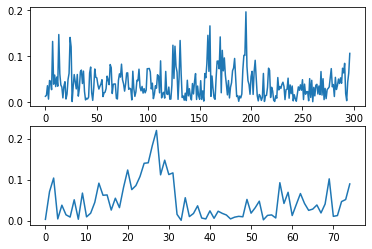

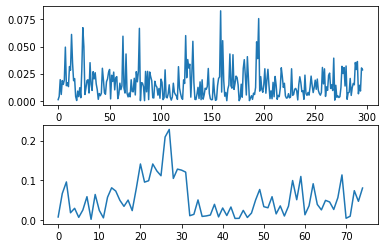

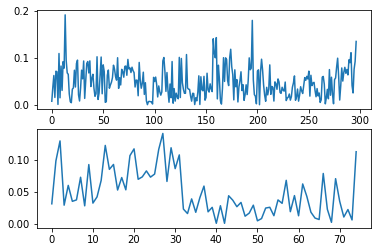

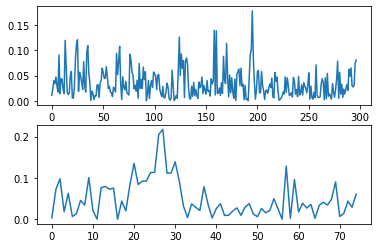

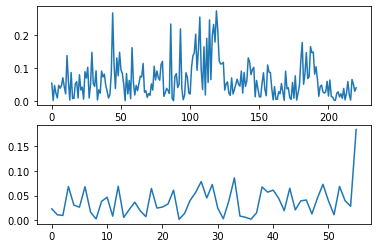

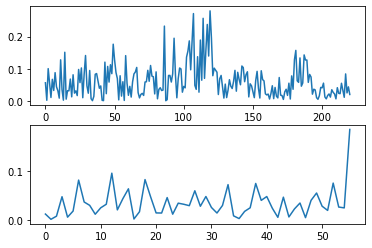

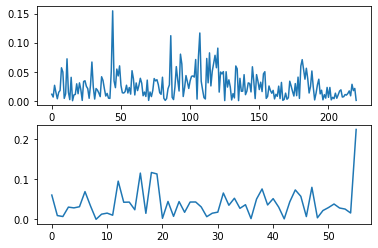

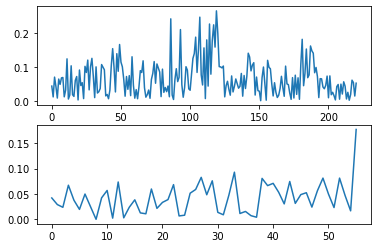

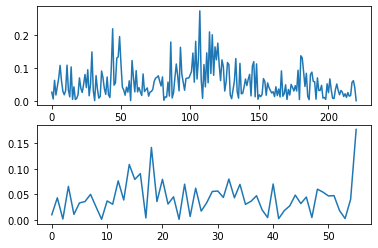

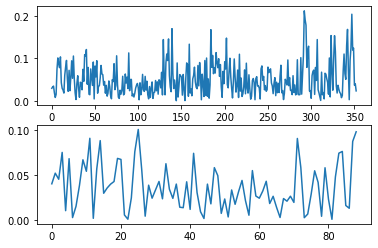

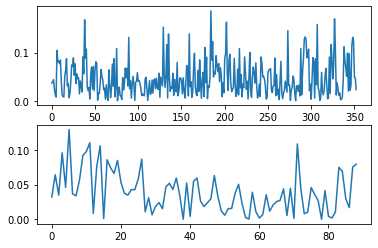

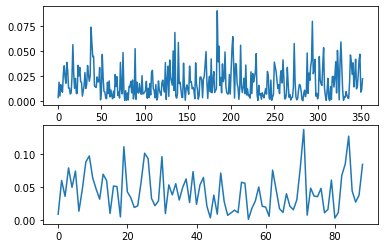

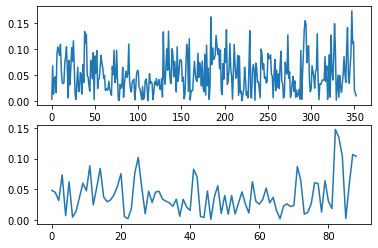

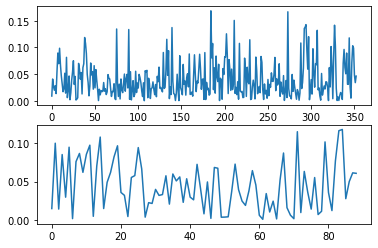

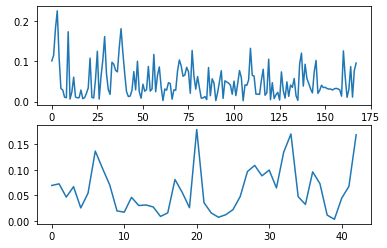

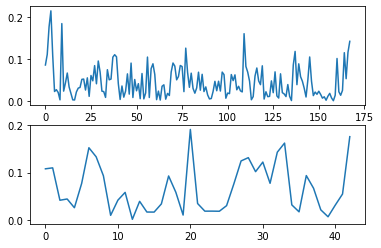

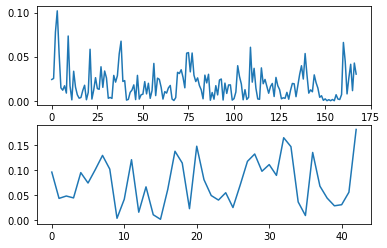

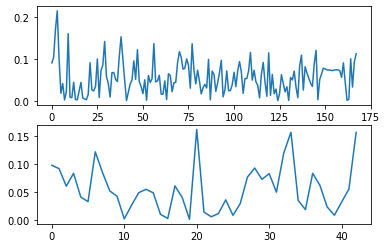

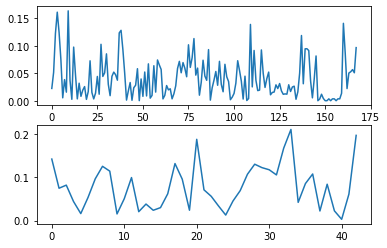

LR
[0.0546644  0.08535763 0.06370152 0.06468775]
[0.05034606 0.04866891 0.04492594 0.07632994]
PR
[0.05078633 0.0811584  0.05815628 0.05952099]
[0.0673058  0.04604455 0.04971454 0.0849494 ]
RFR
[0.0207935  0.03490898 0.0239953  0.02560444]
[0.07226897 0.05520562 0.05262995 0.08828274]
SVR
[0.05828519 0.08434977 0.06301542 0.06785608]
[0.06139615 0.0526567  0.05055308 0.06995887]
KNN
[0.04458391 0.07311077 0.05213549 0.05423849]
[0.06821485 0.05517381 0.05536066 0.0948701 ]

FPS: 30


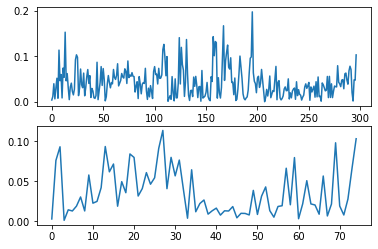

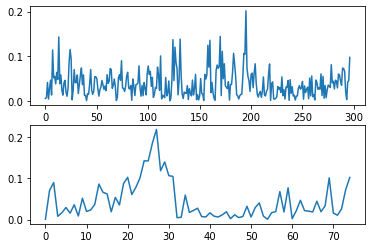

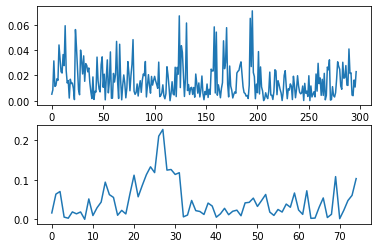

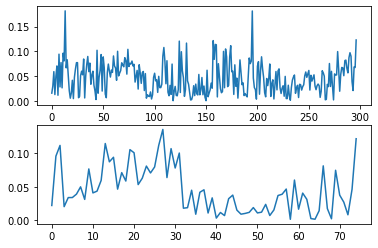

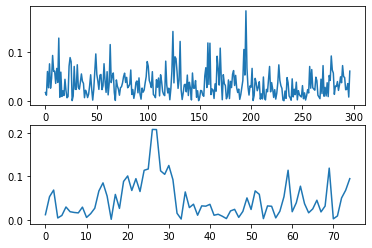

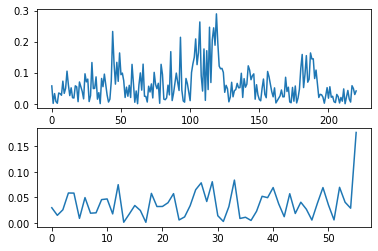

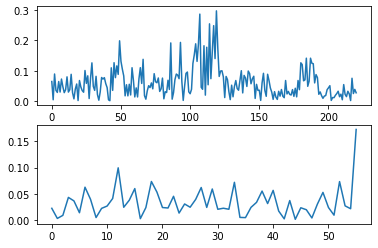

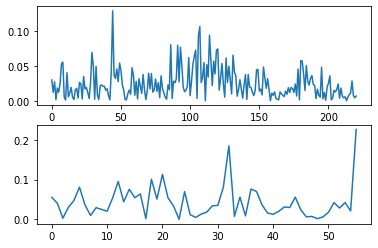

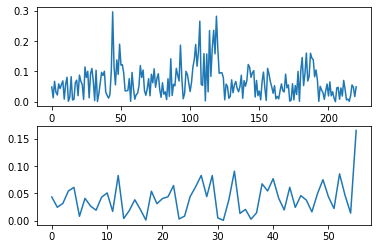

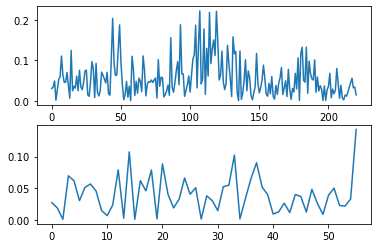

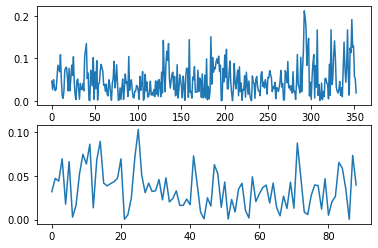

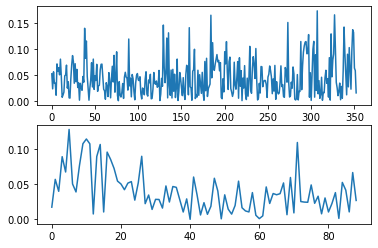

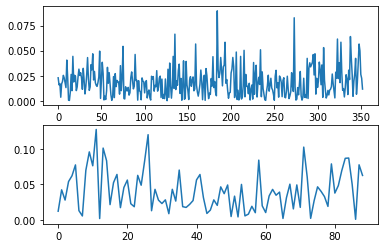

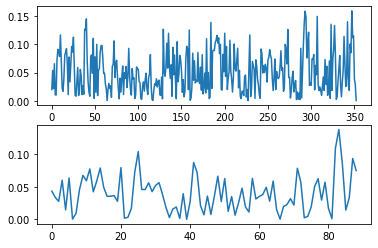

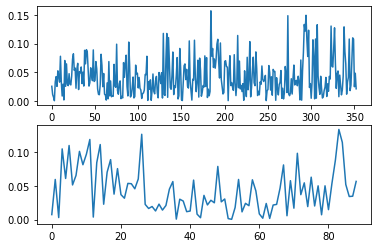

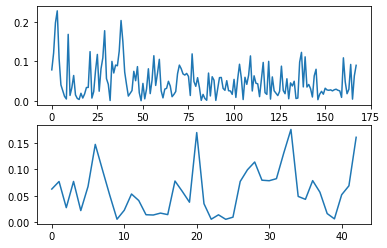

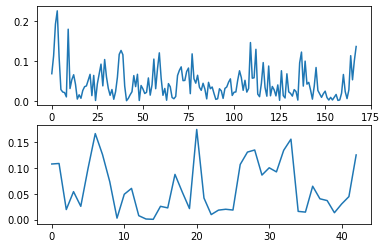

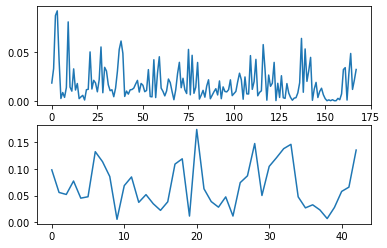

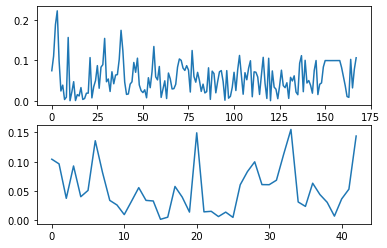

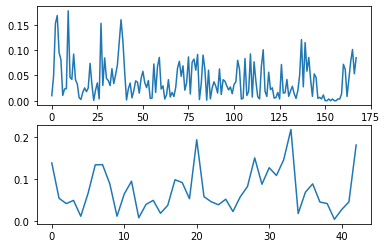

LR
[0.05343563 0.08351459 0.06168857 0.06523187]
[0.04701706 0.04767361 0.04204776 0.07547572]
PR
[0.04909977 0.07993812 0.05639564 0.05943029]
[0.06447944 0.04435132 0.04968815 0.08074276]
RFR
[0.02062533 0.0326596  0.0239699  0.02472806]
[0.06612796 0.05982076 0.05037429 0.08107443]
SVR
[0.05600971 0.08415086 0.06240495 0.06985893]
[0.05749634 0.05019591 0.0484171  0.06797622]
KNN
[0.04389908 0.07216324 0.0526537  0.05478868]
[0.06470433 0.05006657 0.05520134 0.09051916]



In [27]:
for k in range(len(fpss)):
	fps = fpss[k]

	print(f"FPS: {fps}")

	lr_train_mse_list = []
	lr_test_mse_list = []
	pr_train_mse_list = []
	pr_test_mse_list = []
	rfr_train_mse_list = []
	rfr_test_mse_list = []
	svr_train_mse_list = []
	svr_test_mse_list = []
	knn_train_mse_list = []
	knn_test_mse_list = []
	for i in range(len(plot_video_names)):
		video_name = plot_video_names[i]	

		x_all = dataset[video_name][fps]['x_all']
		y_all = dataset[video_name][fps]['y_all']

		x_train, x_test, y_train, y_test = my_train_test_split(x_all, y_all, TEST_SIZE)

		# LR
		lr_train_mse, lr_test_mse = lr_inference(x_train, x_test, y_train, y_test)
		lr_train_mse_list.append(lr_train_mse)
		lr_test_mse_list.append(lr_test_mse)

		# PR
		pr_train_mse, pr_test_mse = pr_inference(x_train, x_test, y_train, y_test)
		pr_train_mse_list.append(pr_train_mse)
		pr_test_mse_list.append(pr_test_mse)

		# RFR
		rfr_train_mse, rfr_test_mse = rfr_inference(x_train, x_test, y_train, y_test)
		rfr_train_mse_list.append(rfr_train_mse)
		rfr_test_mse_list.append(rfr_test_mse)

		# SVR
		svr_train_mse, svr_test_mse = svr_inference(x_train, x_test, y_train, y_test)
		svr_train_mse_list.append(svr_train_mse)
		svr_test_mse_list.append(svr_test_mse)

		# KNN
		knn_train_mse, knn_test_mse = knn_inference(x_train, x_test, y_train, y_test)
		knn_train_mse_list.append(knn_train_mse)
		knn_test_mse_list.append(knn_test_mse)
	
	print(f"LR")
	# print(round(np.sqrt(np.average(np.array(lr_train_mse_list))), 4))
	# print(round(np.sqrt(np.average(np.array(lr_test_mse_list))), 4))
	print(np.array(lr_train_mse_list))
	print(np.array(lr_test_mse_list))

	print(f"PR")
	# print(round(np.sqrt(np.average(np.array(pr_train_mse_list))), 4))
	# print(round(np.sqrt(np.average(np.array(pr_test_mse_list))), 4))
	print(np.array(pr_train_mse_list))
	print(np.array(pr_test_mse_list))

	print(f"RFR")
	# print(round(np.sqrt(np.average(np.array(rfr_train_mse_list))), 4))
	# print(round(np.sqrt(np.average(np.array(rfr_test_mse_list))), 4))
	print(np.array(rfr_train_mse_list))
	print(np.array(rfr_test_mse_list))

	print(f"SVR")
	# print(round(np.sqrt(np.average(np.array(svr_train_mse_list))), 4))
	# print(round(np.sqrt(np.average(np.array(svr_test_mse_list))), 4))
	print(np.array(svr_train_mse_list))
	print(np.array(svr_test_mse_list))
	
	print(f"KNN")
	# print(round(np.sqrt(np.average(np.array(knn_train_mse_list))), 4))
	# print(round(np.sqrt(np.average(np.array(knn_test_mse_list))), 4))
	print(np.array(knn_train_mse_list))
	print(np.array(knn_test_mse_list))

	print(f"")